Llegamos a la sección donde Aurélien Géron expande los árboles de decisión hacia el mundo del **aprendizaje supervisado cuantitativo: la regresión**. Es fascinante ver cómo un algoritmo que mapea reglas lógicas (que parecen puramente cualitativas) puede llegar a predecir números continuos con alta precisión, simplemente cambiando "clases mayoritarias" por "promedios aritméticos".



A continuación, tienes la traducción técnica adaptada al español, las actualizaciones correspondientes y los scripts de Python para reconstruir el árbol de regresión y las gráficas comparativas (Figuras 5-4, 5-5 y 5-6).

---



## 1. Traducción, Corrección y Actualización del Texto

### Regresión



Los árboles de decisión también son capaces de realizar tareas de regresión.

Mientras que la regresión lineal solo funciona bien con datos lineales, los árboles de decisión pueden ajustarse a todo tipo de conjuntos de datos complejos. 

Construyamos un árbol de regresión utilizando la clase `DecisionTreeRegressor` de Scikit-Learn, entrenándolo en un conjunto de datos cuadrático con ruido y configurando `max_depth=2`:



In [1]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

rng = np.random.default_rng(seed=42)
X_quad = rng.random((200, 1)) - 0.5 # una única característica de entrada aleatoria
y_quad = X_quad ** 2 + 0.025 * rng.standard_normal((200, 1))

tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_quad, y_quad)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max


El árbol resultante se representa en la Figura 5-4.

### Figura 5-4. Un árbol de decisión para regresión

Este árbol se ve muy similar al árbol de clasificación que construiste anteriormente. La principal diferencia es que **en lugar de predecir una clase en cada nodo, predice un valor continuo**.

Por ejemplo, supón que deseas realizar una predicción para una nueva instancia con $x_1 = 0.2$. El nodo raíz pregunta si $x_1 \le 0.343$. Como es verdadero, el algoritmo se desplaza al nodo hijo izquierdo, el cual pregunta si $x_1 \le -0.302$. Dado que esto es falso ($0.2$ no es menor que $-0.302$), el algoritmo va al nodo hijo derecho. Este es un nodo hoja y predice un `value=0.038`.

Esta predicción es exactamente el **valor objetivo promedio (media)** de las 133 instancias de entrenamiento asociadas con este nodo hoja, y da como resultado un Error Cuadrático Medio (MSE) igual a 0.002 sobre estas 133 instancias.

Las predicciones de este modelo se representan a la izquierda en la Figura 5-5. Si configuras `max_depth=3`, obtendrás las predicciones representadas a la derecha. Nota cómo el valor predicho para cada región es siempre el valor objetivo promedio de las instancias en esa región. El algoritmo divide cada región de manera que la mayoría de las instancias de entrenamiento queden lo más cerca posible de ese valor predicho.



### Figura 5-5. Predicciones de dos modelos de regresión con árboles de decisión

El algoritmo CART funciona tal como se describió anteriormente, excepto que en lugar de intentar dividir el conjunto de entrenamiento de una manera que minimice la impureza (como Gini), ahora intenta dividir el conjunto de entrenamiento de forma que **minimice el Error Cuadrático Medio (MSE)**. La Ecuación 5-4 muestra la función de costo que el algoritmo intenta minimizar.

#### Ecuación 5-4. Función de costo CART para regresión

$$J(k, t_k) = \frac{m_{\text{izq}}}{m} \text{MSE}_{\text{izq}} + \frac{m_{\text{der}}}{m} \text{MSE}_{\text{der}}$$

Donde:


$$\text{MSE}_{\text{nodo}} = \frac{\sum_{i \in \text{nodo}} (\hat{y}_{\text{nodo}} - y^{(i)})^2}{m_{\text{nodo}}}$$

$$\hat{y}_{\text{nodo}} = \frac{\sum_{i \in \text{nodo}} y^{(i)}}{m_{\text{nodo}}}$$

Al igual que en las tareas de clasificación, los árboles de decisión son propensos al sobreajuste (*overfitting*) cuando se enfrentan a tareas de regresión. Sin ninguna regularización (es decir, utilizando los hiperparámetros por defecto), obtendrás las predicciones que se muestran a la izquierda en la Figura 5-6. Estas predicciones claramente están sobreajustando el conjunto de entrenamiento de forma muy grave. El simple hecho de configurar `min_samples_leaf=10` da como resultado un modelo mucho más razonable, representado a la derecha en la Figura 5-6.

### Figura 5-6. Predicciones de un árbol de regresión sin regularizar (izquierda) y un árbol regularizado (derecha)

---



## 2. Correcciones y Actualizaciones Técnicas

* **Cambio de criterio por defecto en Scikit-Learn:** En las versiones en las que se basó originalmente el texto, el criterio de división por defecto para `DecisionTreeRegressor` era `"mse"`. En las versiones modernas de Scikit-Learn, el valor por defecto se renombró formalmente a `"squared_error"` (aunque bajo el capó realiza exactamente la misma matemática del MSE). También se dispone de `"absolute_error"` (MAE) si buscas un árbol robusto a valores atípicos (*outliers*).
* **Naturaleza discontinua:** Un error conceptual común es olvidar que un árbol de regresión **predice mediante funciones escalonadas (constantes a trozos)**. Al ver las gráficas notarás que las predicciones no son una curva suave, sino una serie de "escalones" planos y horizontales. Si tus datos requieren una predicción continua y fluida, un árbol de decisión individual no es la herramienta ideal (es mejor usar regresiones polinomiales, splines o redes neuronales).

---



## 3. Scripts de Python para Ejemplificar y Visualizar



### Script 1: Estructura del Árbol de Regresión (Figura 5-4)

Este script entrena el modelo y muestra la estructura de decisiones basada en el promedio de los valores.



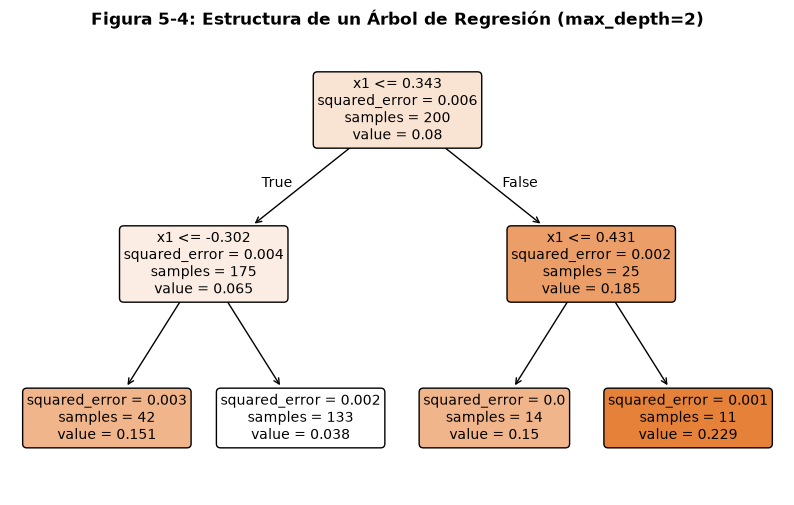

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree

# 1. Replicar el dataset cuadrático con ruido usando la sintaxis moderna de NumPy
rng = np.random.default_rng(seed=42)
X_quad = rng.random((200, 1)) - 0.5
y_quad = X_quad ** 2 + 0.025 * rng.standard_normal((200, 1))

# 2. Entrenar el regresor
tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_quad, y_quad.ravel()) # .ravel() para evitar warnings de dimensiones

# 3. Graficar la estructura del árbol de regresión
plt.figure(figsize=(10, 6), dpi=100)
plot_tree(
    tree_reg,
    feature_names=["x1"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Figura 5-4: Estructura de un Árbol de Regresión (max_depth=2)", fontsize=12, \
    fontweight='bold')
plt.savefig(r"C:\Users\marco\Downloads\regression_tree_structure.png", dpi=300)
plt.show()



# Script 2: El impacto de la Profundidad (`max_depth=2` vs `max_depth=3`) (Figura 5-5)

Este script dibuja las funciones escalonadas resultantes sobre los datos dispersos para ilustrar cómo el algoritmo segmenta el espacio en regiones y calcula la media.



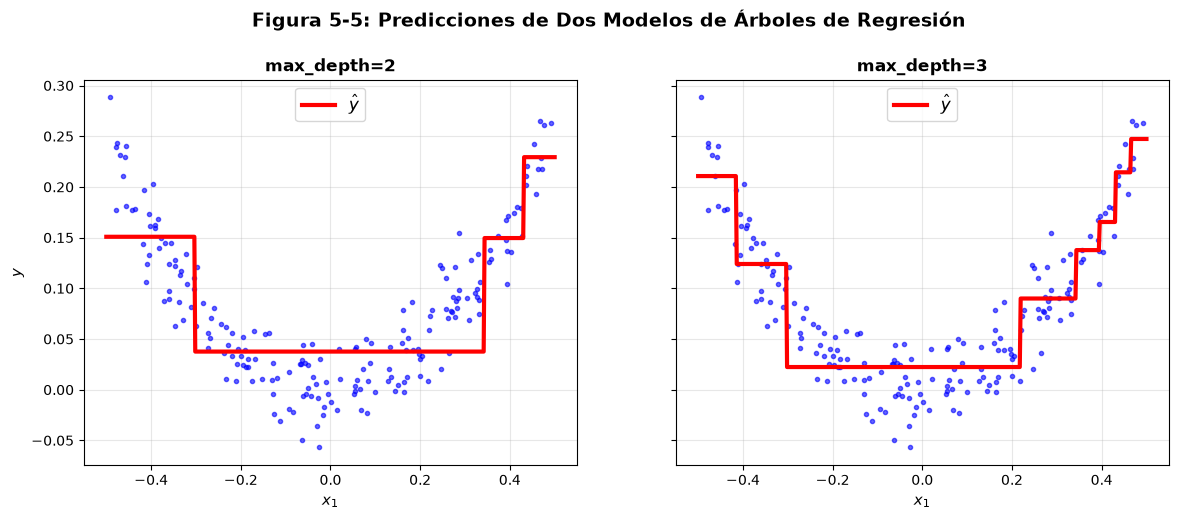

In [3]:
# Crear datos de prueba continuos para dibujar las líneas de predicción escalonadas
X_test = np.linspace(-0.5, 0.5, 500).reshape(-1, 1)

# Entrenar un segundo modelo con mayor profundidad
tree_reg_d3 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_reg_d3.fit(X_quad, y_quad.ravel())

# Predecir con ambos modelos
y_pred_d2 = tree_reg.predict(X_test)
y_pred_d3 = tree_reg_d3.predict(X_test)

# Graficar lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Izquierda: max_depth=2
axes[0].plot(X_quad, y_quad, "b.", alpha=0.6)
axes[0].plot(X_test, y_pred_d2, "r-", linewidth=3, label=r"$\hat{y}$")
axes[0].set_title("max_depth=2", fontsize=12, fontweight='bold')
axes[0].set_xlabel("$x_1$", fontsize=11)
axes[0].set_ylabel("$y$", fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper center", fontsize=12)

# Derecha: max_depth=3
axes[1].plot(X_quad, y_quad, "b.", alpha=0.6)
axes[1].plot(X_test, y_pred_d3, "r-", linewidth=3, label=r"$\hat{y}$")
axes[1].set_title("max_depth=3", fontsize=12, fontweight='bold')
axes[1].set_xlabel("$x_1$", fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper center", fontsize=12)

plt.suptitle("Figura 5-5: Predicciones de Dos Modelos de Árboles de Regresión", \
    fontsize=14, fontweight='bold', y=1.02)
plt.savefig(r"C:\Users\marco\Downloads\regression_tree_predictions.png", dpi=300)
plt.show()



# Script 3: Sobreajuste Extremo frente a Regularización (Figura 5-6)

Finalmente, observemos qué ocurre si dejamos que el árbol crezca sin restricciones frente a controlarlo mediante `min_samples_leaf=10`.



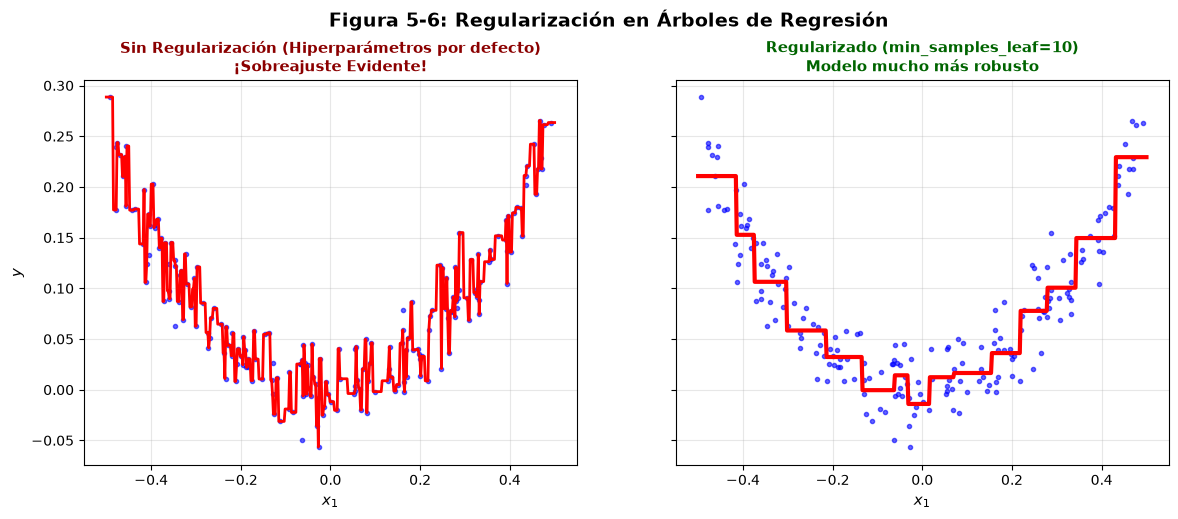

In [4]:
# Entrenar modelo totalmente libre (Sin restricciones -> Sobreajuste masivo)
tree_reg_overfit = DecisionTreeRegressor(random_state=42) # max_depth=None
tree_reg_overfit.fit(X_quad, y_quad.ravel())

# Entrenar modelo regularizado
tree_reg_regularized = DecisionTreeRegressor(min_samples_leaf=10, random_state=42)
tree_reg_regularized.fit(X_quad, y_quad.ravel())

# Predecir
y_pred_overfit = tree_reg_overfit.predict(X_test)
y_pred_regularized = tree_reg_regularized.predict(X_test)

# Graficar comparativa final
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Izquierda: Sin restricciones
axes[0].plot(X_quad, y_quad, "b.", alpha=0.6)
axes[0].plot(X_test, y_pred_overfit, "r-", linewidth=2)
axes[0].set_title("Sin Regularización (Hiperparámetros por defecto)\n¡Sobreajuste Evidente!", fontsize=11, color="darkred", fontweight='bold')
axes[0].set_xlabel("$x_1$", fontsize=11)
axes[0].set_ylabel("$y$", fontsize=11)
axes[0].grid(True, alpha=0.3)

# Derecha: Regularizado con min_samples_leaf=10
axes[1].plot(X_quad, y_quad, "b.", alpha=0.6)
axes[1].plot(X_test, y_pred_regularized, "r-", linewidth=3)
axes[1].set_title("Regularizado (min_samples_leaf=10)\nModelo mucho más robusto", fontsize=11, color="darkgreen", fontweight='bold')
axes[1].set_xlabel("$x_1$", fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Figura 5-6: Regularización en Árboles de Regresión", fontsize=14, \
    fontweight='bold', y=1.02)
plt.savefig(r"C:\Users\marco\Downloads\regression_tree_regularization.png", dpi=300)
plt.show()
